In [19]:
class SVM:
    def __init__(self, lr=0.01, epochs=1000, C=1.0):
        self.lr = lr
        self.epochs = epochs
        self.C = C  # Коэффициент штрафа за ошибки
        self.w1 = 0
        self.w2 = 0
        self.b = 0
        self.loss_history = []

    def predict(self, X):
        return [1 if (self.w1 * x1 + self.w2 * x2 + self.b) >= 0 else -1 for x1, x2 in X]

    def loss_fn(self, X, y):
        loss = 0.5 * (self.w1 ** 2 + self.w2 ** 2)  # L2-норма весов
        for i in range(len(y)):
            margin = y[i] * (self.w1 * X[i][0] + self.w2 * X[i][1] + self.b)
            if margin < 1:
                loss += self.C * (1 - margin)  # hinge loss
        return loss

    def fit(self, X, y):
        n = len(y)
        
        for _ in range(self.epochs):
            dw1, dw2, db = self.w1, self.w2, 0  # Производные от L2-нормы
            
            for i in range(n):
                margin = y[i] * (self.w1 * X[i][0] + self.w2 * X[i][1] + self.b)
                if margin < 1:
                    dw1 -= self.C * y[i] * X[i][0]
                    dw2 -= self.C * y[i] * X[i][1]
                    db -= self.C * y[i]
            
            self.w1 -= self.lr * dw1
            self.w2 -= self.lr * dw2
            self.b -= self.lr * db
            
            self.loss_history.append(self.loss_fn(X, y))

In [15]:
k = int(input())
inp = []
X = []
y = []
for i in range(k):
    inp.append(list(map(int, input().split())))
for x in inp:
    X.append([x[0], x[1]])
    y.append(x[2])

 10
 2 6 -1
 4 -8 1
 9 -1 -1
 5 2 -1
 -9 7 -1
 10 4 -1
 2 -8 1
 -6 -4 1
 -10 -4 1
 -2 8 -1


In [16]:
model = SVM(lr=0.01, epochs=1000, C=1.0)
model.fit(X, y)

print(model.w1, model.w2, model.b)

-0.08609757355284921 -0.28685516255586646 -0.5300000000000002


In [17]:
import matplotlib.pyplot as plt

w1, w2, b = model.w1, model.w2, model.b
x1 = [i for i in range(-10, 11)]
x2 = [-(w1 * x1[i] + b) / w2 for i in range(len(x1))]

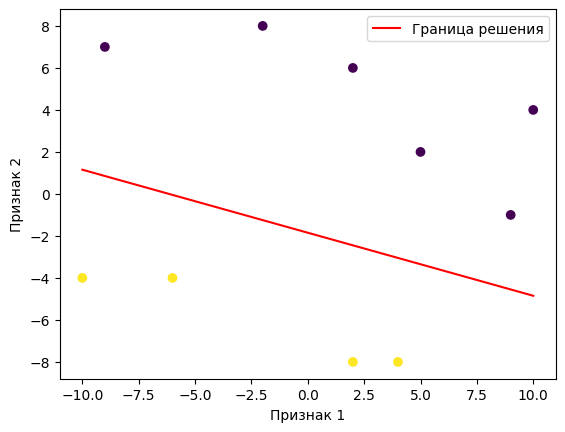

In [18]:
xx, xy = zip(*X)
plt.scatter(xx, xy, c=y, cmap='viridis')
plt.plot(x1, x2, color='red', label='Граница решения')
plt.xlabel("Признак 1")
plt.ylabel("Признак 2")
plt.legend()
plt.show()